# Estimating E[X|Y]: Binning vs Regression in a Gaussian model

This notebook compares two methods for estimating the conditional expectation E[X|Y]:
1. **Binning estimator** - Partition Y into bins and compute mean of X each
2. **Regression Estimator** -Fit a linear model X~Y

We validate both against the **true conditional mean** in a bivariate Gaussian setting.

In [7]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 6.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 6.1 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 6.9 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 7.1 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 6.8 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.7 MB/s  0:00:01

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Bivariate Gaussian Theory
For a bivariate Gaussian $(X,Y) \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma}) $, the conditional expectation is:

$$E[X|Y=y] = \mu_X +\rho \frac{\sigma_X}{\sigma_Y}(y-\mu_Y) $$

This is a **linear function** of Y, which is why linear regression is optimal here

In [9]:
def generate_bivariate_gaussian(n, mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0.7):
    # generate samples from bivariate gaussian distribution
    mean = [mu_x, mu_y]
    cov = [[sigma_x**2, rho*sigma_x*sigma_y], [rho*sigma_x*sigma_y, sigma_y**2]]
    samples = np.random.multivariate_normal(mean, cov, n)
    return samples[:,0], samples[:,1]

def true_conditional_mean(y, mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0.7):
    return mu_x+rho*(sigma_x/sigma_y)*(y-mu_y)

## 2. Binning Estimator
Divide the range of Y into bins and estimate E[X|Y=y] as the sample mean of X values whose corresponding Y falls in the same bin as y

In [14]:
def binning_estimator(x,y,y_query, n_bins=10):
    # returns: estimates E[X|Y] at y_query point, bin_center and bin_means: mean X value in each bin

    bins = np.linspace(y.min(), y.max(), n_bins+1)
    bin_indices = np.digitize(y,bins)-1
    bin_indices = np.clip(bin_indices,0,n_bins-1)

    bin_means = np.zeros(n_bins)
    bin_centers = (bins[:-1]+bins[1:])/2

    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum()>0:
            bin_means[i]=x[mask].mean()
        else:
            bin_means[i]=np.nan

    # interpolate for query points
    query_indices = np.digitize(y_query,bins)-1
    query_indices = np.clip(query_indices,0, n_bins-1)
    estimates = bin_means[query_indices]

    return estimates, bin_centers, bin_means

## 3. Regression Estimator
Fit a linear regression model: $X = \beta_0 + \beta_1 Y +\epsilon$

In [11]:
def regression_estimator(x, y, y_query):
    # estimate E(X|Y) using linear regression
    model = LinearRegression()
    model.fit(y.reshape(-1,1),x)
    estimates = model.predict(y_query.reshape(-1,1))
    return estimates, model

## 4. Generate Data and Compare Methods

In [16]:
# param
n = 1000
mu_x, mu_y = 2, 1
sigma_x, sigma_y = 1.5, 1.0
rho = 0.7

# generate data
X, Y = generate_bivariate_gaussian(n, mu_x, mu_y, sigma_x, sigma_y, rho)

# query points for estimation
y_grid = np.linspace(Y.min(), Y.max(), 100)

# true consitional mean
true_E_X_given_Y = true_conditional_mean(y_grid, mu_x, mu_y, sigma_x, sigma_y, rho)

# binning estimator (10 bins)
binning_est, bin_centers, bin_means = binning_estimator(X, Y, y_grid, n_bins=10)

# Regression estimator
regression_est, reg_model = regression_estimator(X, Y, y_grid)

print(f"Regression coefficients: beta_0 = {reg_model.intercept_:.4f}, beta_1 = {reg_model.coef_[0]:.4f}")
print(f"True slope (rho*sigma_x/sigma_y): {rho* sigma_x/sigma_y:.4f}")

Regression coefficients: beta_0 = 0.9487, beta_1 = 1.0664
True slope (rho*sigma_x/sigma_y): 1.0500


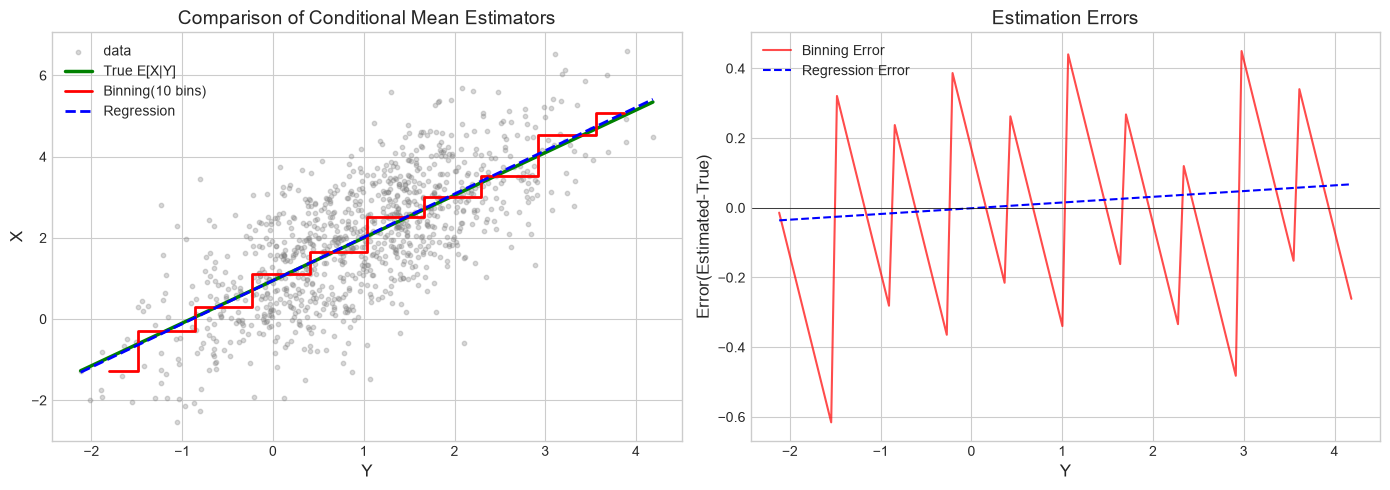

In [19]:
#Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# left plot: scatter with estimators
ax1=axes[0]
ax1.scatter(Y, X, alpha=0.3, s=10, label='data', color='gray')
ax1.plot(y_grid, true_E_X_given_Y, 'g-', linewidth=2.5, label='True E[X|Y]')
ax1.step(bin_centers, bin_means,'r-', linewidth=2, where='mid', label='Binning(10 bins)')
ax1.plot(y_grid, regression_est, 'b--', linewidth=2, label='Regression')
ax1.set_xlabel('Y', fontsize=12)
ax1.set_ylabel('X', fontsize=12)
ax1.set_title('Comparison of Conditional Mean Estimators', fontsize=14)
ax1.legend(fontsize=10)

# Right plot: estimation errors
ax2=axes[1]
binning_error = binning_est - true_E_X_given_Y
regression_error = regression_est - true_E_X_given_Y
ax2.plot(y_grid, binning_error, 'r-', linewidth=1.5, alpha=0.7, label='Binning Error')
ax2.plot(y_grid, regression_error, 'b--', linewidth=1.5, label='Regression Error')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Y', fontsize=12)
ax2.set_ylabel('Error(Estimated-True)',fontsize=12)
ax2.set_title('Estimation Errors', fontsize=14)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
# compute MSE for both estimators
mse_binning = np.nanmean((binning_est-true_E_X_given_Y)**2)
mse_regression = np.nanmean((regression_est-true_E_X_given_Y)**2)

print("="*60)
print("Mean Squared Error VS True Conditional Mean")
print("="*60)
print(f"Binning Estimator (10 bins): MSE={mse_binning:.6f}")
print(f"Regression Estimator MSE={mse_regression:.6f}")
print("="*60)


Mean Squared Error VS True Conditional Mean
Binning Estimator (10 bins): MSE=0.055817
Regression Estimator MSE=0.001156


## 5. Bias-Variance Tradeoff: Effect of Number of Bins

- **Few bins**: High bias (poor approximatiob), low variance
- **Many bins**: Low bias (flexible), high variance (few samples per bin)

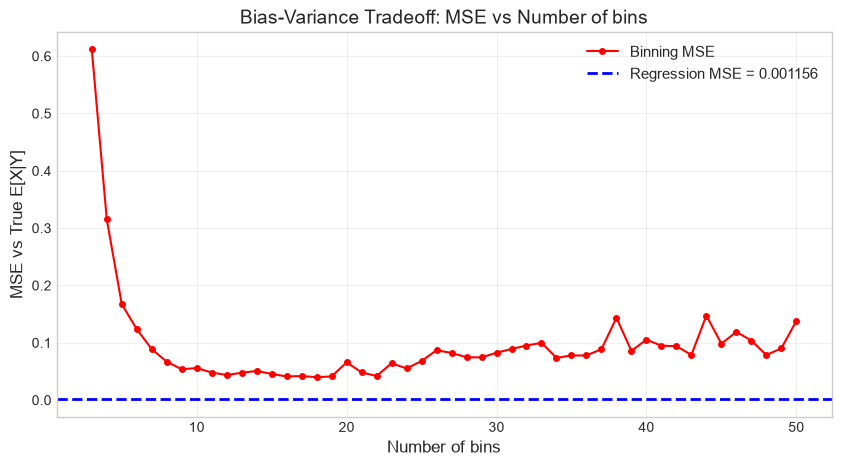


Optimal number of bins:18 (MSE=0.039905)


In [23]:
bin_range = range(3,51)
mse_by_bins = []

for n_bins in bin_range:
    est,_,_ = binning_estimator(X,Y,y_grid, n_bins=n_bins)
    mse = np.nanmean((est-true_E_X_given_Y)**2)
    mse_by_bins.append(mse)

plt.figure(figsize=(10,5))
plt.plot(bin_range, mse_by_bins, 'ro-', markersize=4, label='Binning MSE')
plt.axhline(y=mse_regression, color='blue', linestyle='--', linewidth=2, label=f'Regression MSE = {mse_regression:.6f}')
plt.xlabel('Number of bins', fontsize=12)
plt.ylabel('MSE vs True E[X|Y]', fontsize=12)
plt.title('Bias-Variance Tradeoff: MSE vs Number of bins', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

optimal_bins = bin_range[np.argmin(mse_by_bins)]
print(f"\nOptimal number of bins:{optimal_bins} (MSE={min(mse_by_bins):.6f})")

- **Regression wins for Gaussian Data**: since E[X|Y] is linear in Y for bivariate Gaussian,linear regression is th eoptimal estimator and achieves near-zero MSE
- **Binning has inherent bias**: Even with optimal bin count, binning approximates the true conditional mean with step functions, introducing discretization error.
- **Bias-Variance Tradeoff**: 
    - Too few bins -> underffitting (high bias)
    - Too many bins 6> overfitting (high variance, unstable estimates)

- **Useful Binning**: non-linear conditional expectations where regression assumptions fail, binning is a useful tool.
